# Playground: predict and protect your own society

Define a society and its opinions, see it, get the three predictions
with their certificate, and ask the three questions an intervening
agent asks: whom to persuade, what one edge changes, and how much
adaptivity the society can afford. Every prediction can be verified by
brute force in the last cell.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from adaptive_voting import (validate, voting_power, build_tables, predict, influence,
                             simulate_outcomes, apply_rewire)


## 1. Your society

Edit the next cell. `G` is the listening matrix: row `i` says how agent
`i` splits its attention over the others, so `G[i, j]` is the share of
attention agent `i` gives to agent `j`. Rules: every row sums to one
(row stochastic), all entries are nonnegative, the diagonal is zero
(agents do not listen to themselves), and the society has exactly one
closed class (a group that listens only to itself; everyone else
listens into it, directly or through others). `validate` will tell you
which rule is broken if any. `X` is the opinion of each agent, +1 or
-1, and `P` is the rewiring rate.

The default is the three agent society F1 of the paper, the one whose
first order theory was derived by hand: agent 0 listens to 1, agent 1
listens to 2, agent 2 listens to 1. Nobody listens to agent 0, so it
is voiceless. Section 3b below puts the hand derivation next to the
code. (The four agent society G* of Theorem 1 is the other example of
the paper; its matrix is in a comment.)


In [ ]:
G = np.array([
    [0.0, 1.0, 0.0],   # agent 0 listens to 1 (nobody listens to 0)
    [0.0, 0.0, 1.0],   # agent 1 listens to 2
    [0.0, 1.0, 0.0],   # agent 2 listens to 1
])
X = [+1, +1, -1]
P = 0.05

# The society G* of Theorem 1 (nobody listens to agent 2), with X = [+1, -1, +1, +1]:
# G = np.array([[0., .5, 0., .5], [.5, 0., 0., .5], [.5, 0., 0., .5], [.5, .5, 0., 0.]])

G, x0 = validate(G, np.array(X))
N = G.shape[0]
print(f"{N} agents, {int((G > 0).sum())} edges, rewiring rate {P}")


## 2. See it

Orange holds +1, blue holds -1. Node size is voting power (the static
influence): a tiny node is an agent (almost) nobody listens to.


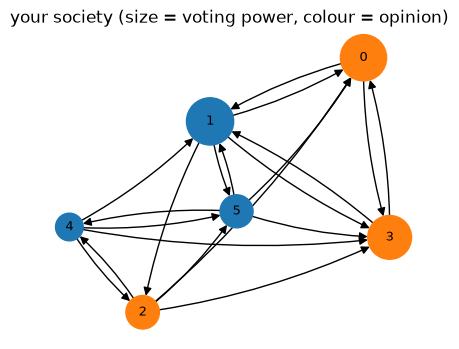

agent 0: opinion +1, voting power 0.269
agent 1: opinion -1, voting power 0.285
agent 2: opinion +1, voting power 0.094
agent 3: opinion +1, voting power 0.232
agent 4: opinion -1, voting power 0.032
agent 5: opinion -1, voting power 0.088


In [3]:
pi = voting_power(G)
Gx = nx.DiGraph()
Gx.add_nodes_from(range(N))
Gx.add_edges_from((i, j) for i, j in zip(*np.nonzero(G > 0)))
pos = nx.spring_layout(Gx, seed=4)
colors = ["tab:orange" if v == 1 else "tab:blue" for v in x0]
sizes = 300 + 3000 * pi
plt.figure(figsize=(5, 4))
nx.draw_networkx(Gx, pos, node_color=colors, node_size=sizes, arrows=True,
                 arrowsize=12, connectionstyle="arc3,rad=0.08", font_size=9)
plt.title("your society (size = voting power, colour = opinion)")
plt.axis("off"); plt.show()
for i in range(N):
    print(f"agent {i}: opinion {x0[i]:+d}, voting power {pi[i]:.3f}")


## 3. Predict

The three endings, the certificate rho (expected rewires per
decision), and its band: calibrated (rho <= 1), degrading (<= 2), out
of range beyond.


In [4]:
rng = np.random.default_rng(0)
report = predict(G, x0, P, n_runs=4000, rng=rng)
print(f"P(+1 wins)      {report['P_plus']:.3f}")
print(f"P(-1 wins)      {report['P_minus']:.3f}")
print(f"P(no consensus) {report['P_none']:.3f}")
print(f"static answer would have been {report['h0']:.3f} for +1")
print(f"certificate: rho = {report['rho']:.2f}  ({report['certificate']})")


P(+1 wins)      0.607
P(-1 wins)      0.393
P(no consensus) 0.000
static answer would have been 0.594 for +1
certificate: rho = 2.93  (out of range)


## 3b. By hand against the code (the pencil proof of the paper)

On F1 at opinions (+1, +1, -1) everything can be done by hand.

**Voting power.** The closed class is {1, 2} (they listen only to each
other), agent 0 is transient, so pi = (0, 1/2, 1/2) and
h0 = (1 + pi . x)/2 = (1 + 0)/2 = 1/2.

**The three legal rewires and their leaks** (pi of the rewired graph
minus pi):
- (0, 1 -> 2): agent 0 moves its attention from 1 to 2; the closed
  class is unchanged, leak (0, 0, 0).
- (1, 2 -> 0): agent 1 now listens to 0; the closed class becomes
  {0, 1} with pi' = (1/2, 1/2, 0), leak (1/2, 0, -1/2).
- (2, 1 -> 0): agent 2 now listens to 0; the graph becomes the cycle
  0 -> 1 -> 2 -> 0 with pi' = (1/3, 1/3, 1/3), leak (1/3, -1/6, -1/6).

**The reward at the starting state.** Only disagreeing pairs with a
candidate count: agent 1 (+1) listening to agent 2 (-1), candidate
set {0} (agrees with 1, not yet listened to), value
leak(1,2,0) . x / 2 = (1/2 - 0 + 1/2)/2 = 1/2, weighted by
(1/N) G[1,2] = 1/3: reward 1/6. Agent 2 (-1) listening to agent 1
(+1) has no candidate (nobody else holds -1). So R(x) = 1/6.

**The first order coefficient.** Solving L_c h1 = -R on the six
transient states with h1 = 0 at consensus gives h1(+1, +1, -1) = 1/4
exactly (and -1/36 at (+1, -1, +1), 0 at (+1, -1, -1)). So the first
order prediction is P(+1) = 1/2 + p/4, which at p = 0.05 is 0.5125.

The next cell prints the code's versions of each of these numbers.


In [ ]:
pi_c, leaks_c, cuts_c = build_tables(G)
print("voting power     code:", np.round(pi_c, 6), "   hand: (0, 0.5, 0.5)")
hand_leaks = {(0, 1, 2): (0, 0, 0), (1, 2, 0): (0.5, 0, -0.5), (2, 1, 0): (1/3, -1/6, -1/6)}
for key, hand in hand_leaks.items():
    print(f"leak {key}   code: {np.round(leaks_c[key], 6)}   hand: {np.round(hand, 6)}")
print(f"h1               code: {report['h1']:.4f} +- {report['h1_se']:.4f}   hand: 0.25")
print(f"P(+1) at p={P}  code: {report['P_plus']:.4f}   hand: {0.5 + P/4:.4f}")
print(f"split coefficient code: {report['f1_none']}   hand: 0 (no single rewire cuts F1)")


## 4. Whom to persuade

The adaptive voting power of every agent: how much the +1 probability
moves if that agent's opinion flips. Hollow bars: the static voting
power pi. Where they differ, adaptivity has changed who matters.


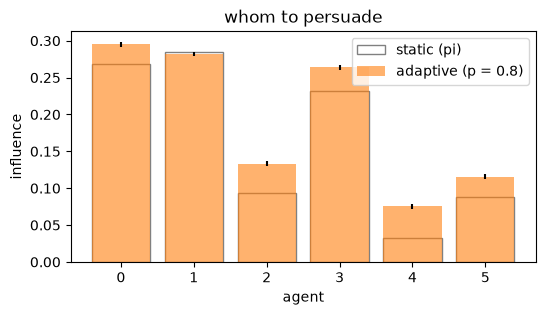

best persuasion target for the +1 side: agent 1 (influence 0.282)


In [5]:
v, v_se = influence(G, x0, P, n_runs=2000, rng=rng)
plt.figure(figsize=(6, 3))
plt.bar(range(N), pi, fill=False, edgecolor="grey", label="static (pi)")
plt.bar(range(N), v, alpha=.6, yerr=v_se, label=f"adaptive (p = {P})")
plt.xlabel("agent"); plt.ylabel("influence"); plt.legend(); plt.title("whom to persuade")
plt.show()
minus_camp = [i for i in range(N) if x0[i] == -1]
if minus_camp:
    best = max(minus_camp, key=lambda i: v[i])
    print(f"best persuasion target for the +1 side: agent {best} (influence {v[best]:.3f})")


## 5. What one edge changes

Pick an action: add a listening edge that does not exist yet (the
listener starts giving it an equal share of its attention) or make one rewire
(`R_I` stops listening to `R_J` in favour of `R_K`). Set the unused
action to None. The cell reports the three probabilities before and
after.


In [6]:
ADD_EDGE = (0, 2)   # (listener, new target), an edge that does not exist yet; or None
REWIRE = None          # (i, j, k) or None

G_new = G.copy()
if ADD_EDGE is not None:
    a, b = ADD_EDGE
    if a == b:
        raise ValueError("an agent cannot listen to itself")
    if G_new[a, b] > 0:
        raise ValueError(f"agent {a} already listens to {b}; pick an absent edge, or use REWIRE to move an existing one")
    d = int((G_new[a] > 0).sum())
    G_new[a] *= d / (d + 1)
    G_new[a, b] = 1 / (d + 1)
if REWIRE is not None:
    G_new = apply_rewire(G_new, *REWIRE)

before = predict(G, x0, P, n_runs=4000, rng=np.random.default_rng(1))
after = predict(G_new, x0, P, n_runs=4000, rng=np.random.default_rng(1))
for key, label in (("P_plus", "P(+1)"), ("P_minus", "P(-1)"), ("P_none", "P(split)")):
    print(f"{label:>9}: {before[key]:.3f} -> {after[key]:.3f}   ({after[key]-before[key]:+.3f})")


    P(+1): 0.607 -> 0.607   (+0.000)
    P(-1): 0.393 -> 0.393   (+0.000)
 P(split): 0.000 -> 0.000   (+0.000)


## 6. How much adaptivity can this society afford?

The predicted split probability as the rewiring rate grows, in units
of rho; the marked point is the fragility budget, where the risk of a
split reaches 10 percent.


no single rewire cuts this society: splitting, if it happens at all, needs several rewires,
and the two term budget does not apply (dense societies: negligible risk; rings: see the paper).
split risk stays below 10 percent up to rho = 2.5


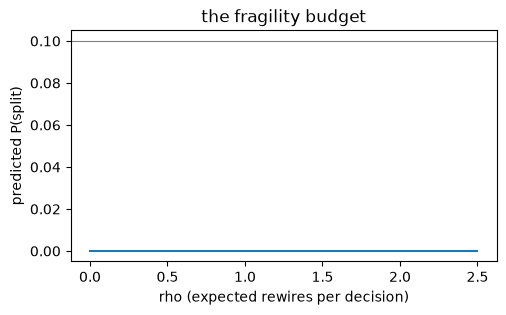

In [7]:
est = predict(G, x0, 0.0, n_runs=4000, rng=np.random.default_rng(2))   # coefficients at p = 0
rhos = np.linspace(0, 2.5, 60)
# two term split prediction as a function of rho: p f1_none + a rho^2 / 2, with p = rho / E[D]
if est["f1_none"] == 0.0:
    print("no single rewire cuts this society: splitting, if it happens at all, needs several rewires,")
    print("and the two term budget does not apply (dense societies: negligible risk; rings: see the paper).")
split = [est["f1_none"] * r / max(est["E_D"], 1e-9) + (0.038 * r**2 / 2 if est["f1_none"] > 0 else 0.0) for r in rhos]
plt.figure(figsize=(5.5, 3))
plt.plot(rhos, split)
plt.axhline(0.10, color="grey", lw=.8)
over = [r for r, s in zip(rhos, split) if s >= 0.10]
if over:
    plt.axvline(over[0], color="tab:red", lw=.8)
    print(f"fragility budget: about rho = {over[0]:.2f} rewires per decision (p = {over[0]/max(est['E_D'],1e-9):.3f})")
else:
    print("split risk stays below 10 percent up to rho = 2.5")
plt.xlabel("rho (expected rewires per decision)"); plt.ylabel("predicted P(split)")
plt.title("the fragility budget"); plt.show()


## 7. Do not trust us: verify

Runs the real adaptive process and compares. z is the distance in
standard errors; anything within about 2 is agreement, and the
certificate above told you when to expect it.


In [8]:
sim = simulate_outcomes(G, x0, P, 20000, np.random.default_rng(3))
for pk, sk, label in (("P_plus", "+1", "P(+1)"), ("P_minus", "-1", "P(-1)"), ("P_none", "none", "P(split)")):
    # a zero count over n games still has uncertainty about 1/n: floor the error there
    se = max(sim[sk + "_se"], 1.0 / 20000)
    print(f"{label:>9}: predicted {report[pk]:.3f}   measured {sim[sk]:.3f} +- {se:.3f}   z = {abs(report[pk]-sim[sk])/se:.1f}")


    P(+1): predicted 0.607   measured 0.682 +- 0.005   z = 16.0
    P(-1): predicted 0.393   measured 0.318 +- 0.005   z = 16.0
 P(split): predicted 0.000   measured 0.000 +- 0.000   z = 0.0
